Importing Required Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

Converting the Image to Grayscale

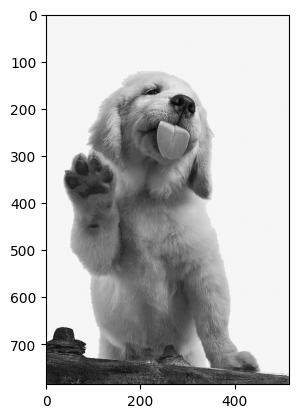

(785, 516)

In [15]:
img = cv2.imread('f2a01e86c920a43c10b65128e272f94f.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.show()
img.shape


Creating the Salt Pepper Function

In [4]:
def add_salt_pepper_noise(img, probability = 0.3):
    noisy = img.copy()
    random = np.random.rand(*img.shape)

    noisy[random < (probability / 2)] = 0
    noisy[random > 1 - (probability / 2)] = 255

    return noisy


Defining the Probability and Calling the Function

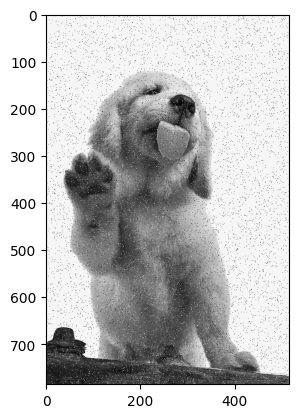

In [18]:
probability = 0.04

noisy = add_salt_pepper_noise(img, probability)

plt.imshow(noisy, cmap='gray')

Code to show a transition from 0 noise to 1.0 noise

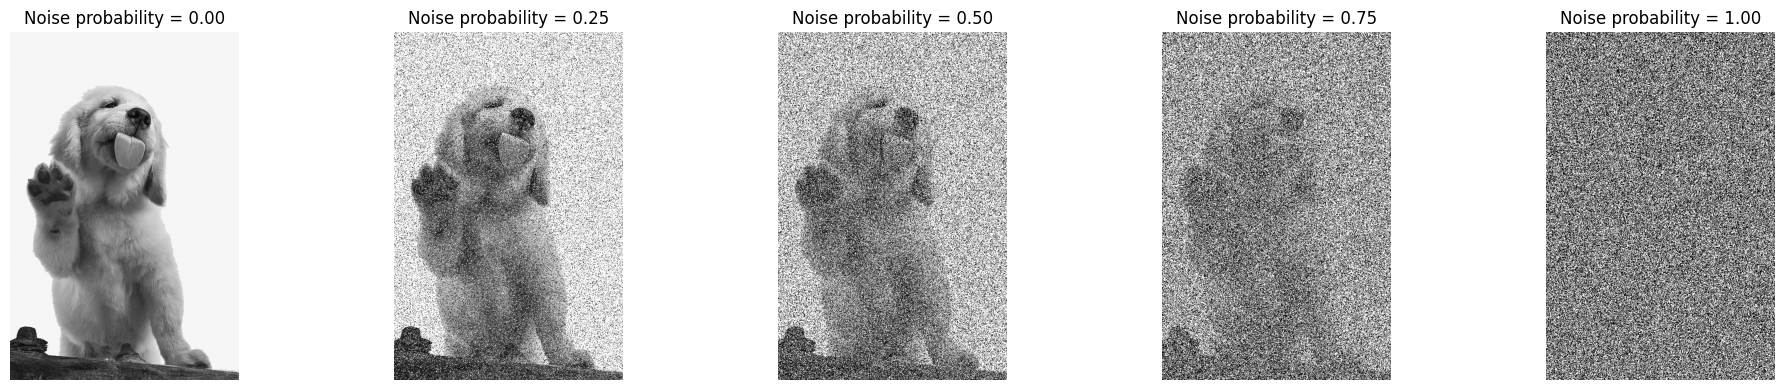

In [ ]:
probabilities = np.arange(0, 1.1, 0.25)

fig, axes = plt.subplots(1, len(probabilities), figsize=(20, 4))

for ax, p in zip(axes, probabilities):
    noisy = add_salt_pepper_noise(img, p)
    ax.imshow(noisy, cmap='gray')
    ax.set_title(f"Noise probability = {p:.2f}")
    ax.axis('off')

plt.tight_layout()
plt.show()

Using the Moving Window to remove the Salt Pepper Noise

In [ ]:
def median_filter(img, window_size=3):
    pad = window_size // 2
    padded = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_REFLECT)
    result = np.zeros_like(img, dtype=np.uint8)

    h = 785
    w = 516
    for i in range(h):
        for j in range(w):
            window = padded[i:i+window_size, j:j+window_size]
            result[i, j] = np.median(window)

    return result

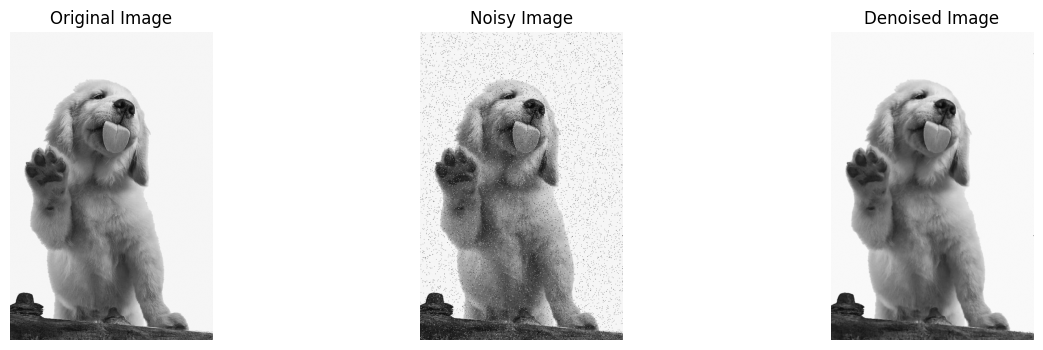

In [ ]:
probability = 0.04
noisy = add_salt_pepper_noise(img, probability)
denoised = median_filter(noisy, 3)
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(noisy, cmap='gray')
plt.title('Noisy Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(denoised, cmap='gray')
plt.title('Denoised Image')
plt.axis('off')

plt.show()